# EEG Lab — Notebook 2: cleaning the signal (filtering)

**Goal:** understand why and how to filter an EEG signal, and do it in Python with `scipy`.

A raw signal contains things we don't want: slow drift, electrical mains noise (50 Hz in Europe), high-frequency noise. **Filtering** keeps only the useful frequencies (roughly 1 to 40 Hz for classic EEG).

## 1. Reload the data and one channel


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch

df = pd.read_csv('eeg_data.csv')
fs = 250
o1 = df['O1'].to_numpy()
time = np.arange(len(o1)) / fs
print("Data ready:", len(o1), "points.")

Data ready: 15000 points.


## 2. Define a band-pass filter function

A **function** is a small reusable program. We define it with `def`. This one keeps frequencies between `low` and `high` hertz.

Key idea: the **Nyquist frequency** equals `fs / 2`. It's the highest frequency you can measure. We express the filter bounds relative to it.

In [2]:
def band_pass(signal, low, high, fs, order=4):
    """Keep frequencies between 'low' and 'high' Hz."""
    nyquist = fs / 2
    b, a = butter(order, [low/nyquist, high/nyquist], btype='band')
    return filtfilt(b, a, signal)   # filtfilt = filtering without time shift

print("Function 'band_pass' defined.")

Function 'band_pass' defined.


## 3. Define a notch filter at 50 Hz

Mains electricity pollutes the EEG at **50 Hz**. A *notch* filter removes exactly that frequency.

In [3]:
def notch_50hz(signal, fs, freq=50.0, quality=30.0):
    """Remove the mains frequency (50 Hz)."""
    b, a = iirnotch(freq, quality, fs)
    return filtfilt(b, a, signal)

print("Function 'notch_50hz' defined.")

Function 'notch_50hz' defined.


## 4. Apply the filters

We chain them: first the 1–40 Hz band-pass, then the 50 Hz notch.

In [4]:
o1_filtered = band_pass(o1, 1, 40, fs)
o1_filtered = notch_50hz(o1_filtered, fs)

print("Filtering done.")

Filtering done.


## 5. Compare before / after

We overlay the two signals over the first 5 seconds.

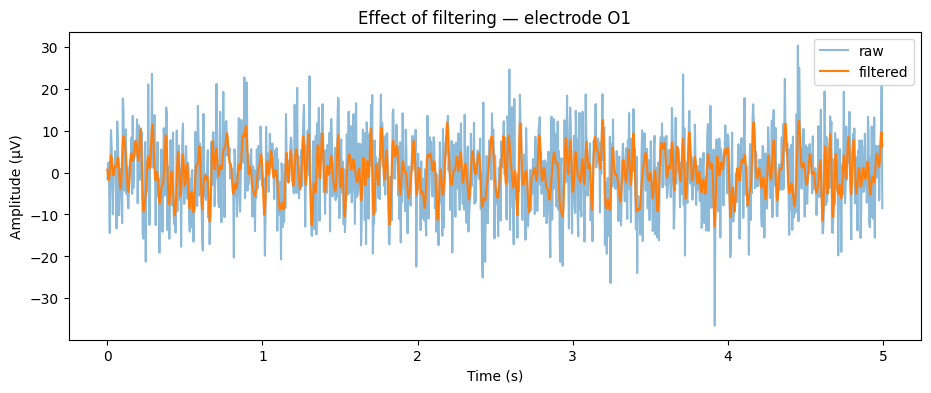

In [5]:
mask = time < 5

plt.figure(figsize=(11, 4))
plt.plot(time[mask], o1[mask], label='raw', alpha=0.5)
plt.plot(time[mask], o1_filtered[mask], label='filtered', linewidth=1.5)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.title("Effect of filtering — electrode O1")
plt.legend()
plt.show()

## 🧠 Your turn

1. Filter electrode **O2** and plot before/after.
2. Try a band-pass of **8–12 Hz** (the alpha band) on O1. What is left of the signal? What does it look like?

*Hint: `band_pass(o1, 8, 12, fs)`.*

In [6]:
# Your code here
